# 09. 자연어 처리 기초 (NLP Basics)

이번 장에서는 텍스트 데이터를 모델에 넣기 전에 거쳐야 하는 **전처리(preprocessing)** 과정을 다룬다. 크롤링 등으로 얻은 코퍼스는 그대로 쓸 수 없으므로, **토큰화 → 정제·정규화 → 불용어 제거 → 정규 표현식 정제 → 정수 인코딩 → 패딩**의 단계를 거쳐 모델이 다룰 수 있는 형태로 가공한다.

> **이 장의 흐름** : 토큰화(Tokenization) → 정제(Cleaning)와 정규화(Normalization) → 불용어(Stopwords) → 정규 표현식(Regular Expression) → 딥 러닝을 위한 전처리 실습(단어 집합·정수 인코딩·패딩).
>
> 앞 장들의 모델링과 달리, 이 장은 **데이터를 어떻게 손질하느냐**가 핵심이다. 같은 모델이라도 전처리 품질에 따라 성능이 크게 달라지므로, 각 단계가 무엇을 왜 하는지 정확히 이해하는 것이 중요하다.

> **실행 환경 안내** : 이 노트는 NLTK, KoNLPy, Mecab, spaCy, KSS 등 외부 패키지와 데이터 다운로드가 필요하다. Colab에서 위에서부터 차례로 실행하되, 설치 셀(`!pip install ...`, `nltk.download(...)`)을 먼저 실행해야 한다. **Colab의 Gemini 자동 수정은 변수명을 임의로 바꾸거나 불필요한 import를 끼워 넣을 수 있으므로, 자동 수정 제안 대신 `런타임 → 모두 실행`(`Ctrl/Cmd+F9`)을 사용한다.**

# 1. 토큰화 (Tokenization)

주어진 코퍼스(corpus)에서 **토큰(token)**이라 불리는 단위로 나누는 작업을 **토큰화(tokenization)**라고 한다. 토큰의 단위는 상황에 따라 다르지만, 보통 **의미 있는 단위**로 정의한다. 여기서는 토큰화에서 발생할 수 있는 여러 상황을 통해 개념을 이해한 뒤, NLTK·KoNLPy로 실습한다.

## 1-1. 단어 토큰화 (Word Tokenization)

토큰의 기준을 단어(word)로 하는 경우를 **단어 토큰화**라고 한다. 여기서 단어는 단어 단위 외에 단어구, 의미를 갖는 문자열로도 간주된다.

예를 들어 `Time is an illusion. Lunchtime double so!` 라는 입력에서 구두점을 제외하고 띄어쓰기를 기준으로 자르면 다음 토큰을 얻는다.

```
"Time", "is", "an", "illusion", "Lunchtime", "double", "so"
```

> 다만 이는 가장 기초적인 예시일 뿐이다. 보통 토큰화는 단순히 구두점·특수문자를 전부 제거하는 정제 작업만으로 해결되지 않는다. 구두점을 전부 지우면 토큰이 의미를 잃기도 하고, 띄어쓰기만으로 단어가 구분되는 영어와 달리 **한국어는 띄어쓰기만으로 단어 토큰을 구분하기 어렵다.**

## 1-2. 토큰화 중 생기는 선택의 순간

토큰화를 하다 보면 기준을 고민해야 하는 경우가 생긴다. 대표적으로 영어의 **아포스트로피(`'`)**가 들어간 단어가 그렇다. 예컨대 `Don't`, `Jone's`는 다음처럼 여러 갈래로 토큰화할 수 있다.

`Don't` → `Don't` / `Don t` / `Dont` / `Do n't`
`Jone's` → `Jone's` / `Jone s` / `Jone` / `Jones`

어떤 기준이 옳은지는 **데이터의 사용 목적**에 따라 정해진다. 직접 도구를 설계할 수도 있지만, 공개된 도구의 결과가 목적과 맞다면 그것을 쓰면 된다. NLTK의 `word_tokenize`, `WordPunctTokenizer`, 케라스의 `text_to_word_sequence`가 아포스트로피를 어떻게 처리하는지 비교해 본다.

In [1]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
from nltk.tokenize import word_tokenize
from nltk.tokenize import WordPunctTokenizer
from tensorflow.keras.preprocessing.text import text_to_word_sequence

text = "Don't be fooled by the dark sounding name, Mr. Jone's Orphanage is as cheery as cheery goes for a pastry shop."

print('단어 토큰화1 :', word_tokenize(text))
# word_tokenize : Don't → 'Do' + "n't" , Jone's → 'Jone' + "'s"

print('단어 토큰화2 :', WordPunctTokenizer().tokenize(text))
# WordPunctTokenizer : 구두점을 별도 분리 → Don't → 'Don' + "'" + 't"

print('단어 토큰화3 :', text_to_word_sequence(text))
# text_to_word_sequence : 소문자화 + 구두점 제거, 단 don't / jone's 의 아포스트로피는 보존

단어 토큰화1 : ['Do', "n't", 'be', 'fooled', 'by', 'the', 'dark', 'sounding', 'name', ',', 'Mr.', 'Jone', "'s", 'Orphanage', 'is', 'as', 'cheery', 'as', 'cheery', 'goes', 'for', 'a', 'pastry', 'shop', '.']
단어 토큰화2 : ['Don', "'", 't', 'be', 'fooled', 'by', 'the', 'dark', 'sounding', 'name', ',', 'Mr', '.', 'Jone', "'", 's', 'Orphanage', 'is', 'as', 'cheery', 'as', 'cheery', 'goes', 'for', 'a', 'pastry', 'shop', '.']
단어 토큰화3 : ["don't", 'be', 'fooled', 'by', 'the', 'dark', 'sounding', 'name', 'mr', "jone's", 'orphanage', 'is', 'as', 'cheery', 'as', 'cheery', 'goes', 'for', 'a', 'pastry', 'shop']


> 세 도구의 차이를 정리하면 다음과 같다.
> - **`word_tokenize`** : `Don't` → `Do`, `n't` / `Jone's` → `Jone`, `'s` 로 분리한다.
> - **`WordPunctTokenizer`** : 구두점을 독립 토큰으로 본다. `Don't` → `Don`, `'`, `t`.
> - **`text_to_word_sequence`** : 모든 알파벳을 소문자로 바꾸고 구두점을 제거하되, `don't`·`jone's`의 아포스트로피는 보존한다.
>
> 정답이 하나로 정해진 것이 아니라 **목적에 맞는 도구를 고르는 것**이 핵심이다.

## 1-3. 토큰화에서 고려해야 할 사항

토큰화를 "구두점 제거 후 공백 분리"로 단순화할 수 없는 이유를 정리한다.

**1) 구두점이나 특수 문자를 단순 제외해서는 안 된다.**
마침표(`.`)는 문장 경계를 알려 주므로 남겨 둘 수 있다. 단어 자체에 구두점이 있는 경우(`m.p.h`, `Ph.D`, `AT&T`)도 있고, 특수 문자가 의미를 갖는 경우도 있다. `$45.55`는 가격, `01/02/06`은 날짜이며, `123,456,789`처럼 숫자 사이의 컴마는 자릿수 구분이다. 이런 경우 `45`와 `55`로 쪼개고 싶지 않을 수 있다.

**2) 줄임말과 단어 내 띄어쓰기.**
영어의 아포스트로피는 압축된 단어를 펼치는 역할도 한다. `what're`는 `what are`, `we're`는 `we are`의 줄임말이며, 이때 `re`를 **접어(clitic)**라고 한다. 또 `New York`, `rock 'n' roll`처럼 하나의 단어인데 중간에 띄어쓰기가 있는 경우도 있으므로, 토큰화는 이런 단어를 하나로 인식할 수 있어야 한다.

## 1-4. 표준 토큰화 예제 (Penn Treebank Tokenization)

표준으로 쓰이는 토큰화 규칙 중 하나인 **Penn Treebank Tokenization**의 규칙은 다음과 같다.

> **규칙 1.** 하이픈으로 구성된 단어는 하나로 유지한다.
> **규칙 2.** `doesn't`처럼 아포스트로피로 접어가 함께하는 단어는 분리한다.

In [3]:
from nltk.tokenize import TreebankWordTokenizer

tokenizer = TreebankWordTokenizer()
text = "Starting a home-based restaurant may be an ideal. it doesn't have a food chain or restaurant of their own."

print('트리뱅크 워드토크나이저 :', tokenizer.tokenize(text))
# home-based → 하나로 유지 (규칙1), doesn't → 'does' + "n't" 로 분리 (규칙2)

트리뱅크 워드토크나이저 : ['Starting', 'a', 'home-based', 'restaurant', 'may', 'be', 'an', 'ideal.', 'it', 'does', "n't", 'have', 'a', 'food', 'chain', 'or', 'restaurant', 'of', 'their', 'own', '.']


## 1-5. 문장 토큰화 (Sentence Tokenization)

토큰의 단위가 문장(sentence)인 경우로, **문장 분류(sentence segmentation)**라고도 한다. 직관적으로는 `?`, `.`, `!`로 자르면 될 것 같지만, **마침표는 문장의 끝이 아니어도 등장**하기 때문에 단순 분리는 위험하다.

> EX1) `IP 192.168.56.31 서버에 ... aaa@gmail.com로 결과 좀 보내줘. 그 후 점심 먹으러 가자.`
> EX2) `Since I'm actively looking for Ph.D. students, I get the same question a dozen times every year.`
>
> 위 문장을 마침표만으로 자르면 `192.168...`, `Ph.D.`처럼 중간 마침표에서 잘못 끊긴다. NLTK의 `sent_tokenize`는 이런 경우를 고려해 문장을 구분한다.

In [4]:
from nltk.tokenize import sent_tokenize

text = "His barber kept his word. But keeping such a huge secret to himself was driving him crazy. Finally, the barber went up a mountain and almost to the edge of a cliff. He dug a hole in the midst of some reeds. He looked about, to make sure no one was near."
print('문장 토큰화1 :', sent_tokenize(text))

문장 토큰화1 : ['His barber kept his word.', 'But keeping such a huge secret to himself was driving him crazy.', 'Finally, the barber went up a mountain and almost to the edge of a cliff.', 'He dug a hole in the midst of some reeds.', 'He looked about, to make sure no one was near.']


In [5]:
# 문장 중간에 마침표가 여러 번 등장하는 경우 (Ph.D.)
text = "I am actively looking for Ph.D. students. and you are a Ph.D student."
print('문장 토큰화2 :', sent_tokenize(text))
# Ph.D. 를 문장 내 단어로 인식 → 마침표를 단순 구분자로 쓰지 않았음을 확인

문장 토큰화2 : ['I am actively looking for Ph.D. students.', 'and you are a Ph.D student.']


한국어 문장 토큰화에는 박상길님이 개발한 **KSS(Korean Sentence Splitter)**를 추천한다.

In [6]:
!pip install kss

In [7]:
import kss

text = '딥 러닝 자연어 처리가 재미있기는 합니다. 그런데 문제는 영어보다 한국어로 할 때 너무 어렵습니다. 이제 해보면 알걸요?'
print('한국어 문장 토큰화 :', kss.split_sentences(text))

한국어 문장 토큰화 : ['딥 러닝 자연어 처리가 재미있기는 합니다.', '그런데 문제는 영어보다 한국어로 할 때 너무 어렵습니다.', '이제 해보면 알걸요?']


## 1-6. 한국어에서의 토큰화의 어려움

영어는 `New York` 같은 합성어나 `he's` 같은 줄임말만 예외 처리하면, **띄어쓰기 토큰화**만으로도 단어 토큰화가 잘 작동한다. 대부분 단어 단위로 띄어쓰기가 되기 때문이다. 하지만 한국어는 그렇지 않다.

**1) 교착어의 특성.**
한국어는 **교착어**다. 즉 조사·어미 등을 붙여 말을 만든다. 띄어쓰기 단위를 **어절**이라 하는데, 어절 토큰화는 한국어 NLP에서 지양된다. 예를 들어 `그`라는 단어 하나에 `그가`, `그에게`, `그를`, `그와`, `그는`처럼 다양한 조사가 띄어쓰기 없이 붙는다. 같은 단어가 조사 때문에 다른 단어로 인식되면 처리가 번거로워지므로, **조사를 분리해야 한다.**

그래서 한국어 토큰화에서는 **형태소(morpheme)** 개념이 필수다. 형태소는 뜻을 가진 가장 작은 말의 단위이며 두 종류가 있다.

- **자립 형태소** : 접사·어미·조사와 상관없이 자립하여 단어가 되는 형태소. 체언(명사·대명사·수사), 수식언(관형사·부사), 감탄사 등.
- **의존 형태소** : 다른 형태소와 결합하여 쓰이는 형태소. 접사·어미·조사·어간.

예: 문장 `에디가 책을 읽었다`
- 띄어쓰기 토큰화 → `['에디가', '책을', '읽었다']`
- 형태소 분해 → 자립: `에디`, `책` / 의존: `-가`, `-을`, `읽-`, `-었`, `-다`

> 결국 한국어에서 영어의 단어 토큰화와 유사한 결과를 얻으려면 어절 토큰화가 아니라 **형태소 토큰화(morpheme tokenization)**를 수행해야 한다.

**2) 한국어는 띄어쓰기가 영어보다 잘 지켜지지 않는다.**
한국어는 띄어쓰기가 없어도 의미 파악이 비교적 쉬운 언어다(모아쓰기 방식). 그래서 많은 코퍼스에서 띄어쓰기가 무시되거나 틀린 경우가 많아 처리가 더 어렵다.

## 1-7. 품사 태깅 (Part-of-speech tagging)

같은 표기라도 품사에 따라 의미가 달라진다. 영어 `fly`는 동사면 '날다', 명사면 '파리'다. 한국어 `못`도 명사면 '망치로 박는 못', 부사면 '~할 수 없다'는 뜻이다. 단어의 의미를 제대로 파악하려면 어떤 품사로 쓰였는지가 중요하므로, 토큰화 과정에서 품사를 구분해 두는 작업을 **품사 태깅(POS tagging)**이라고 한다.

## 1-8. NLTK와 KoNLPy를 이용한 토큰화 실습

**영어** : NLTK는 Penn Treebank POS Tags 기준으로 품사를 태깅한다.

In [8]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')             # 최신 NLTK는 punkt_tab 도 필요할 수 있다
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [9]:
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag

text = "I am actively looking for Ph.D. students. and you are a Ph.D. student."
tokenized_sentence = word_tokenize(text)

print('단어 토큰화 :', tokenized_sentence)
print('품사 태깅 :', pos_tag(tokenized_sentence))

단어 토큰화 : ['I', 'am', 'actively', 'looking', 'for', 'Ph.D.', 'students', '.', 'and', 'you', 'are', 'a', 'Ph.D.', 'student', '.']
품사 태깅 : [('I', 'PRP'), ('am', 'VBP'), ('actively', 'RB'), ('looking', 'VBG'), ('for', 'IN'), ('Ph.D.', 'NNP'), ('students', 'NNS'), ('.', '.'), ('and', 'CC'), ('you', 'PRP'), ('are', 'VBP'), ('a', 'DT'), ('Ph.D.', 'NNP'), ('student', 'NN'), ('.', '.')]


> Penn Treebank POS Tags 약어 : **PRP**(인칭 대명사), **VBP**(동사), **RB**(부사), **VBG**(현재분사), **IN**(전치사), **NNP**(고유 명사), **NNS**(복수형 명사), **CC**(접속사), **DT**(관사).

**한국어** : KoNLPy(코엔엘파이)를 사용한다. 형태소 분석기로 **Okt(Open Korea Text), 메캅(Mecab), 코모란(Komoran), 한나눔(Hannanum), 꼬꼬마(Kkma)**가 있다. 공통 메소드는 `morphs`(형태소 추출), `pos`(품사 태깅), `nouns`(명사 추출)다.

In [10]:
!pip install konlpy

In [11]:
from konlpy.tag import Okt
from konlpy.tag import Kkma

okt = Okt()
kkma = Kkma()

print('OKT 형태소 분석 :', okt.morphs("열심히 코딩한 당신, 연휴에는 여행을 가봐요"))
print('OKT 품사 태깅 :', okt.pos("열심히 코딩한 당신, 연휴에는 여행을 가봐요"))
print('OKT 명사 추출 :', okt.nouns("열심히 코딩한 당신, 연휴에는 여행을 가봐요"))

OKT 형태소 분석 : ['열심히', '코딩', '한', '당신', ',', '연휴', '에는', '여행', '을', '가봐요']
OKT 품사 태깅 : [('열심히', 'Adverb'), ('코딩', 'Noun'), ('한', 'Josa'), ('당신', 'Noun'), (',', 'Punctuation'), ('연휴', 'Noun'), ('에는', 'Josa'), ('여행', 'Noun'), ('을', 'Josa'), ('가봐요', 'Verb')]
OKT 명사 추출 : ['코딩', '당신', '연휴', '여행']


In [12]:
print('꼬꼬마 형태소 분석 :', kkma.morphs("열심히 코딩한 당신, 연휴에는 여행을 가봐요"))
print('꼬꼬마 품사 태깅 :', kkma.pos("열심히 코딩한 당신, 연휴에는 여행을 가봐요"))
print('꼬꼬마 명사 추출 :', kkma.nouns("열심히 코딩한 당신, 연휴에는 여행을 가봐요"))

꼬꼬마 형태소 분석 : ['열심히', '코딩', '하', 'ㄴ', '당신', ',', '연휴', '에', '는', '여행', '을', '가보', '아요']
꼬꼬마 품사 태깅 : [('열심히', 'MAG'), ('코딩', 'NNG'), ('하', 'XSV'), ('ㄴ', 'ETD'), ('당신', 'NP'), (',', 'SP'), ('연휴', 'NNG'), ('에', 'JKM'), ('는', 'JX'), ('여행', 'NNG'), ('을', 'JKO'), ('가보', 'VV'), ('아요', 'EFN')]
꼬꼬마 명사 추출 : ['코딩', '당신', '연휴', '여행']


> 형태소 추출·품사 태깅 결과를 보면 **조사를 기본적으로 분리**하고 있음을 확인할 수 있다. 각 분석기는 성능과 결과가 다르므로, 용도에 맞는 것을 고르면 된다. 예를 들어 **속도를 중시한다면 메캅(Mecab)**을 쓸 수 있다.

# 2. 정제와 정규화 (Cleaning and Normalization)

토큰화 작업 전후에는 텍스트를 용도에 맞게 손질하는 일이 함께한다.

- **정제(cleaning)** : 코퍼스로부터 **노이즈 데이터를 제거**한다.
- **정규화(normalization)** : 표현 방법이 다른 단어들을 **통합해 같은 단어로** 만든다.

> 정제는 토큰화에 방해되는 부분을 없애기 위해 토큰화보다 먼저 이뤄지기도 하고, 토큰화 이후 남은 노이즈를 지우기 위해 지속적으로 이뤄지기도 한다. 완벽한 정제는 어려워서, 대부분 "이 정도면 됐다"는 합의점을 찾는다.

## 2-1. 규칙에 기반한 표기가 다른 단어들의 통합

같은 의미인데 표기가 다른 단어를 하나로 정규화할 수 있다. `USA`와 `US`, `uh-huh`와 `uhhuh`가 그 예다. 이런 정규화를 거치면 `US`를 검색해도 `USA`를 함께 찾을 수 있다. 뒤에서 표기가 다른 단어를 통합하는 방법인 **어간 추출(stemming)**과 **표제어 추출(lemmatization)**을 더 자세히 다룬다.

## 2-2. 대, 소문자 통합

영어권에서 대문자는 문장 맨 앞 등 특정 상황에서만 쓰이고 대부분의 글은 소문자이므로, **대문자를 소문자로 바꾸는 소문자 변환**이 단어 개수를 줄이는 정규화 방법이 된다. 예컨대 `Automobile`을 소문자화하면 `automobile` 검색으로도 찾을 수 있다.

> 단, 무작정 통합하면 안 된다. 미국을 뜻하는 `US`와 우리를 뜻하는 `us`는 구분되어야 하고, 회사명(`General Motors`)·사람 이름(`Bush`)은 대문자로 유지되는 것이 옳다. 정교하게는 머신 러닝 시퀀스 모델로 소문자화 시점을 결정할 수도 있으나, 결국 예외를 크게 고려하지 않고 **모든 코퍼스를 소문자로 바꾸는 것**이 종종 더 실용적인 해결책이 된다.

## 2-3. 불필요한 단어의 제거

정제에서 제거할 **노이즈 데이터**는 (1) 자연어가 아니면서 의미 없는 글자(특수 문자 등)뿐 아니라 (2) 분석 목적에 맞지 않는 불필요 단어도 포함한다. 제거 방법으로 **불용어 제거**(다음 절), **등장 빈도가 적은 단어 제거**, **길이가 짧은 단어 제거**가 있다.

**1) 등장 빈도가 적은 단어.** 예를 들어 100,000개의 메일로 스팸 분류기를 만들 때, 전체에서 5번밖에 안 나온 단어는 분류에 거의 도움이 되지 않는다.

**2) 길이가 짧은 단어.** 영어는 길이가 짧은 단어 상당수가 불용어이고, 짧은 단어를 지우면 구두점까지 함께 제거되는 부수 효과도 있다. 영어 단어 평균 길이는 6~7, 한국어는 2~3 정도로 추정된다. 한국어는 한 글자에 함축적 의미가 담기는 경우가 많아(예: '학교'=배울 학+학교 교) **길이 기반 제거가 잘 통하지 않는다.**

> 영어에서 길이 1인 단어를 제거하면 관사 `a`와 주어 `I`가, 길이 2를 제거하면 `it`, `at`, `to`, `on`, `in`, `by` 등 대부분 불용어가 제거된다. 단, 길이 3까지 제거하면 `fox`, `dog`, `car` 같은 명사도 사라지기 시작하므로 주의가 필요하다.

In [13]:
import re

text = "I was wondering if anyone out there could enlighten me on this car."

# 길이가 1~2인 단어를 정규 표현식으로 삭제
shortword = re.compile(r'\W*\b\w{1,2}\b')
print(shortword.sub('', text))
# 결과 : ' was wondering anyone out there could enlighten this car.'

 was wondering anyone out there could enlighten this car.


## 2-4. 정규 표현식 (Regular Expression)

코퍼스에서 노이즈의 특징을 잡아낼 수 있다면, **정규 표현식**으로 한 번에 제거할 수 있다. HTML 문서의 태그, 뉴스 기사마다 붙는 게재 시간처럼 **반복적으로 등장하는 글자**를 규칙 기반으로 제거할 때 매우 유용하다. (위 2-3절의 짧은 단어 제거에도 이미 정규 표현식이 쓰였다.) 자세한 내용은 4장에서 다룬다.

# 3. 불용어 (Stopwords)

유의미한 단어 토큰만 선별하려면 **큰 의미가 없는 단어 토큰을 제거**해야 한다. 자주 등장하지만 분석에 도움이 되지 않는 단어들 — `I`, `my`, `me`, `over`, 조사, 접미사 등 — 을 **불용어(stopword)**라고 한다. NLTK는 100여 개 이상의 영어 불용어를 미리 정의해 두었으며, 개발자가 직접 정의할 수도 있다.

> NLTK 실습에는 NLTK Data가 필요하다. 데이터가 없다는 에러가 나면 `nltk.download(필요한_데이터)`로 받는다.

## 3-1. NLTK에서 불용어 확인하기

`stopwords.words("english")`는 NLTK가 정의한 영어 불용어 리스트를 리턴한다. 100개가 넘으므로 앞 10개만 확인한다.

In [14]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words_list = stopwords.words('english')
print('불용어 개수 :', len(stop_words_list))
print('불용어 10개 출력 :', stop_words_list[:10])
# 불용어 개수 : 179
# ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're"]

불용어 개수 : 198
불용어 10개 출력 : ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 3-2. NLTK를 통해서 불용어 제거하기

단어 토큰화 결과에서 불용어 집합에 없는 단어만 남긴다.

In [15]:
from nltk.tokenize import word_tokenize

example = "Family is not an important thing. It's everything."
stop_words = set(stopwords.words('english'))

word_tokens = word_tokenize(example)
result = [word for word in word_tokens if word not in stop_words]

print('불용어 제거 전 :', word_tokens)
print('불용어 제거 후 :', result)
# 'is', 'not', 'an' 등이 제거됨

불용어 제거 전 : ['Family', 'is', 'not', 'an', 'important', 'thing', '.', 'It', "'s", 'everything', '.']
불용어 제거 후 : ['Family', 'important', 'thing', '.', 'It', "'s", 'everything', '.']


## 3-3. 한국어에서 불용어 제거하기

한국어는 토큰화 후 조사·접속사 등을 제거하는 방법이 간단하다. 다만 명사·형용사 중에도 제거하고 싶은 단어가 생기므로, 결국 **사용자가 직접 불용어 사전을 만드는 경우**가 많다. 아래 불용어는 임의 선정한 것으로 실제 기준은 아니다.

> 보편적인 한국어 불용어 리스트 예시 : https://www.ranks.nl/stopwords/korean (절대적 기준은 아니다.)
> 불용어가 많으면 코드에 직접 쓰지 않고 txt·csv로 정리해 두고 불러와서 쓰기도 한다.

In [16]:
from konlpy.tag import Okt

okt = Okt()
example = "고기를 아무렇게나 구우려고 하면 안 돼. 고기라고 다 같은 게 아니거든. 예컨대 삼겹살을 구울 때는 중요한 게 있지."
stop_words = "를 아무렇게나 구 우려 고 안 돼 같은 게 구울 때 는"

stop_words = set(stop_words.split(' '))
word_tokens = okt.morphs(example)
result = [word for word in word_tokens if not word in stop_words]

print('불용어 제거 전 :', word_tokens)
print('불용어 제거 후 :', result)

불용어 제거 전 : ['고기', '를', '아무렇게나', '구', '우려', '고', '하면', '안', '돼', '.', '고기', '라고', '다', '같은', '게', '아니거든', '.', '예컨대', '삼겹살', '을', '구울', '때', '는', '중요한', '게', '있지', '.']
불용어 제거 후 : ['고기', '하면', '.', '고기', '라고', '다', '아니거든', '.', '예컨대', '삼겹살', '을', '중요한', '있지', '.']


# 4. 정규 표현식 (Regular Expression)

파이썬은 정규 표현식 모듈 **`re`**를 지원한다. 특정 규칙이 있는 텍스트를 빠르게 정제할 수 있다. 먼저 문법(특수 문자·문자 규칙)과 모듈 함수를 표로 정리한 뒤, 예시로 하나씩 이해한다.

> 표만으로는 이해하기 어렵다. 아래 실습 코드와 표를 **함께** 보며 익히는 것이 좋다.

## 4-1. 정규 표현식 문법

**특수 문자**

| 특수 문자 | 설명 |
|:---:|---|
| `.` | 한 개의 임의의 문자 (줄바꿈 `\n` 제외) |
| `?` | 앞의 문자가 0개 또는 1개 |
| `*` | 앞의 문자가 0개 이상 |
| `+` | 앞의 문자가 1개 이상 |
| `^` | 뒤의 문자열로 **시작** |
| `$` | 앞의 문자열로 **끝** |
| `{숫자}` | 숫자만큼 반복 |
| `{숫자1,숫자2}` | 숫자1 이상 숫자2 이하 반복 (`?`,`*`,`+` 대체 가능) |
| `{숫자,}` | 숫자 이상 반복 |
| `[ ]` | 대괄호 안 문자 중 하나와 매치. `[a-z]`처럼 범위 지정 가능, `[a-zA-Z]`는 알파벳 전체 |
| `[^문자]` | 해당 문자를 **제외**한 문자와 매치 |
| `A\|B` | A 또는 B |

**역슬래시(`\`) 문자 규칙**

| 문자 규칙 | 설명 |
|:---:|---|
| `\\` | 역슬래시 문자 자체 |
| `\d` | 모든 숫자, `[0-9]`와 동일 |
| `\D` | 숫자를 제외한 문자, `[^0-9]`와 동일 |
| `\s` | 공백, `[ \t\n\r\f\v]`와 동일 |
| `\S` | 공백을 제외한 문자, `[^ \t\n\r\f\v]`와 동일 |
| `\w` | 문자 또는 숫자, `[a-zA-Z0-9]`와 동일 |
| `\W` | 문자·숫자가 아닌 문자, `[^a-zA-Z0-9]`와 동일 |

> **실무 팁** : 파이썬에서 정규식 패턴은 `re.compile(r"\d+")`처럼 **원시 문자열(raw string, `r"..."`)**로 쓰는 것이 좋다. 그래야 `\d`, `\s` 등이 파이썬 문자열 이스케이프로 해석되어 경고가 뜨는 일을 막을 수 있다.

## 4-2. 정규 표현식 모듈 함수

| 모듈 함수 | 설명 |
|---|---|
| `re.compile()` | 정규 표현식을 컴파일한다. 자주 쓰는 패턴은 미리 컴파일하면 속도·편의 면에서 유리하다. |
| `re.search()` | 문자열 **전체**에서 매치되는지 검색한다. |
| `re.match()` | 문자열의 **처음**이 매치되는지 검색한다. |
| `re.split()` | 정규 표현식을 기준으로 분리해 리스트로 리턴한다. |
| `re.findall()` | 매치되는 **모든** 문자열을 리스트로 리턴한다. 없으면 빈 리스트. |
| `re.finditer()` | 매치되는 모든 경우에 대한 이터레이터 객체를 리턴한다. |
| `re.sub()` | 매치되는 부분을 다른 문자열로 대체한다. |

> 아래 실습에서는 `re.compile()`로 패턴을 컴파일하고 `re.search()`로 매치 여부를 확인한다. `search()`는 매치되면 **Match Object**를, 매치되지 않으면 아무 값도 리턴하지 않는다(`None`).

## 4-3. 기호별 실습

각 기호가 어떻게 매치되는지 `print()`로 직접 확인한다. (매치 실패 시 `None`이 출력된다.)

In [17]:
import re

# . : 한 개의 임의의 문자
r = re.compile(r"a.c")
print(r.search("kkk"))   # None
print(r.search("abc"))   # <re.Match object; span=(0, 3), match='abc'>

None
<re.Match object; span=(0, 3), match='abc'>


In [18]:
# ? : 앞 문자가 0개 또는 1개  (ab?c → abc, ac 모두 매치)
r = re.compile(r"ab?c")
print(r.search("abbc"))  # None
print(r.search("abc"))   # match='abc'
print(r.search("ac"))    # match='ac'

None
<re.Match object; span=(0, 3), match='abc'>
<re.Match object; span=(0, 2), match='ac'>


In [19]:
# * : 앞 문자가 0개 이상  (ab*c → ac, abc, abbbbc ...)
r = re.compile(r"ab*c")
print(r.search("a"))       # None
print(r.search("ac"))      # match='ac'
print(r.search("abc"))     # match='abc'
print(r.search("abbbbc"))  # match='abbbbc'

None
<re.Match object; span=(0, 2), match='ac'>
<re.Match object; span=(0, 3), match='abc'>
<re.Match object; span=(0, 6), match='abbbbc'>


In [20]:
# + : 앞 문자가 1개 이상  (ab+c → ac 는 매치 안 됨)
r = re.compile(r"ab+c")
print(r.search("ac"))      # None
print(r.search("abc"))     # match='abc'
print(r.search("abbbbc"))  # match='abbbbc'

None
<re.Match object; span=(0, 3), match='abc'>
<re.Match object; span=(0, 6), match='abbbbc'>


In [21]:
# ^ : 시작 문자열 지정  (^ab → ab 로 시작해야 매치)
r = re.compile(r"^ab")
print(r.search("bbc"))   # None
print(r.search("zab"))   # None
print(r.search("abz"))   # match='ab'

None
None
<re.Match object; span=(0, 2), match='ab'>


In [22]:
# {숫자} : 숫자만큼 반복  (ab{2}c → b 가 정확히 2개)
r = re.compile(r"ab{2}c")
print(r.search("ac"))        # None
print(r.search("abc"))       # None
print(r.search("abbc"))      # match='abbc'
print(r.search("abbbbbc"))   # None

None
None
<re.Match object; span=(0, 4), match='abbc'>
None


In [23]:
# {숫자1,숫자2} : 숫자1 이상 숫자2 이하 반복  (ab{2,8}c → b 가 2~8개)
r = re.compile(r"ab{2,8}c")
print(r.search("abc"))            # None
print(r.search("abbc"))           # match='abbc'
print(r.search("abbbbbbbbc"))     # match (b 8개)
print(r.search("abbbbbbbbbc"))    # None (b 9개)

None
<re.Match object; span=(0, 4), match='abbc'>
<re.Match object; span=(0, 10), match='abbbbbbbbc'>
None


In [24]:
# {숫자,} : 숫자 이상 반복  ({0,}=*, {1,}=+)  (a{2,}bc → a 가 2개 이상)
r = re.compile(r"a{2,}bc")
print(r.search("bc"))           # None
print(r.search("aabc"))         # match='aabc'
print(r.search("aaaaaaaabc"))   # match='aaaaaaaabc'

None
<re.Match object; span=(0, 4), match='aabc'>
<re.Match object; span=(0, 10), match='aaaaaaaabc'>


In [25]:
# [ ] : 안의 문자 중 하나와 매치  ([abc] == [a-c])
r = re.compile(r"[abc]")
print(r.search("zzz"))   # None
print(r.search("baac"))  # match='b' (가장 먼저 매치된 한 글자)

# 범위 지정 : 소문자 알파벳
r = re.compile(r"[a-z]")
print(r.search("AAA"))   # None
print(r.search("111"))   # None
print(r.search("aBC"))   # match='a'

None
<re.Match object; span=(0, 1), match='b'>
None
None
<re.Match object; span=(0, 1), match='a'>


In [26]:
# [^문자] : 해당 문자를 제외한 문자와 매치
r = re.compile(r"[^abc]")
print(r.search("a"))   # None
print(r.search("b"))   # None
print(r.search("d"))   # match='d'
print(r.search("1"))   # match='1'

None
None
<re.Match object; span=(0, 1), match='d'>
<re.Match object; span=(0, 1), match='1'>


## 4-4. 정규 표현식 모듈 함수 예제

**1) `re.match()`와 `re.search()`의 차이.** `search()`는 문자열 전체를 보지만, `match()`는 **문자열의 첫 부분부터** 매치되는지 본다. 중간에 패턴이 있어도 시작에서 일치하지 않으면 `match()`는 찾지 않는다.

In [27]:
import re

r = re.compile(r"ab.")
print(r.match("kkkabc"))   # None  (시작이 ab. 와 불일치)
print(r.search("kkkabc"))  # match='abc' (전체에서 매치)
print(r.match("abckkk"))   # match='abc' (시작에서 매치)

None
<re.Match object; span=(3, 6), match='abc'>
<re.Match object; span=(0, 3), match='abc'>


In [28]:
# 2) re.split() : 정규 표현식 기준으로 분리 → 토큰화에 유용
text = "사과 딸기 수박 메론 바나나"
print(re.split(" ", text))      # 공백 기준
# ['사과', '딸기', '수박', '메론', '바나나']

text = "사과\n딸기\n수박\n메론\n바나나"
print(re.split("\n", text))     # 줄바꿈 기준

text = "사과+딸기+수박+메론+바나나"
print(re.split(r"\+", text))    # '+' 기준 ('+'는 특수문자라 이스케이프)

['사과', '딸기', '수박', '메론', '바나나']
['사과', '딸기', '수박', '메론', '바나나']
['사과', '딸기', '수박', '메론', '바나나']


In [29]:
# 3) re.findall() : 매치되는 모든 문자열을 리스트로 리턴 (없으면 [])
text = "이름 : 김철수\n전화번호 : 010 - 1234 - 1234\n나이 : 30\n성별 : 남"

print(re.findall(r"\d+", text))        # ['010', '1234', '1234', '30']
print(re.findall(r"\d+", "문자열입니다."))  # []  (숫자가 없으면 빈 리스트)

['010', '1234', '1234', '30']
[]


In [30]:
# 4) re.sub() : 매치되는 부분을 다른 문자열로 대체 (정제에 자주 사용)
text = "Regular expression : A regular expression, regex or regexp[1] (sometimes called a rational expression)[2][3] is, in theoretical computer science and formal language theory, a sequence of characters that define a search pattern."

preprocessed_text = re.sub('[^a-zA-Z]', ' ', text)  # 알파벳 외 문자는 공백으로
print(preprocessed_text)

Regular expression   A regular expression  regex or regexp     sometimes called a rational expression        is  in theoretical computer science and formal language theory  a sequence of characters that define a search pattern 


## 4-5. 정규 표현식 텍스트 전처리 예제

테이블 형식의 데이터를 텍스트로 저장한 뒤, 정규 표현식으로 원하는 값만 추출한다.

In [31]:
import re

text = "100 John PROF\n101 James STUD\n102 Mac STUD"

# \s+ : 1개 이상의 공백을 기준으로 분리
print(re.split(r'\s+', text))
# ['100', 'John', 'PROF', '101', 'James', 'STUD', '102', 'Mac', 'STUD']

['100', 'John', 'PROF', '101', 'James', 'STUD', '102', 'Mac', 'STUD']


In [32]:
# \d+ : 숫자만 추출
print(re.findall(r'\d+', text))          # ['100', '101', '102']

# [A-Z] : 대문자 '하나씩' 모두 추출 (문자열 단위가 아님)
print(re.findall(r'[A-Z]', text))        # ['J', 'P', 'R', 'O', 'F', 'J', ...]

# [A-Z]{4} : 대문자가 연속 4번 등장하는 경우
print(re.findall(r'[A-Z]{4}', text))     # ['PROF', 'STUD', 'STUD']

# [A-Z][a-z]+ : 첫 글자 대문자 + 소문자 여러 개 → 이름 추출
print(re.findall(r'[A-Z][a-z]+', text))  # ['John', 'James', 'Mac']

['100', '101', '102']
['J', 'P', 'R', 'O', 'F', 'J', 'S', 'T', 'U', 'D', 'M', 'S', 'T', 'U', 'D']
['PROF', 'STUD', 'STUD']
['John', 'James', 'Mac']


## 4-6. 정규 표현식을 이용한 토큰화

NLTK의 **`RegexpTokenizer`**는 정규 표현식으로 단어 토큰화를 수행한다. 괄호 안에 하나의 토큰으로 규정할 정규 표현식을 넣는다.

- `tokenizer1`의 `\w+` : 문자 또는 숫자가 1개 이상인 경우를 토큰으로 본다.
- `tokenizer2`의 `gaps=True` : 해당 정규 표현식을 토큰을 **나누는 기준(구분자)**으로 사용한다는 의미다. (`gaps=True`를 빼면 공백만 토큰으로 나온다.)

In [33]:
from nltk.tokenize import RegexpTokenizer

text = "Don't be fooled by the dark sounding name, Mr. Jone's Orphanage is as cheery as cheery goes for a pastry shop"

tokenizer1 = RegexpTokenizer(r"[\w]+")          # 문자/숫자 1개 이상을 토큰으로
tokenizer2 = RegexpTokenizer(r"\s+", gaps=True)  # 공백을 분리 기준으로

print(tokenizer1.tokenize(text))
# 아포스트로피·온점이 제거됨 : ['Don', 't', ..., 'Mr', 'Jone', 's', ...]

print(tokenizer2.tokenize(text))
# 아포스트로피·온점이 보존됨 : ["Don't", ..., 'name,', 'Mr.', "Jone's", ...]

['Don', 't', 'be', 'fooled', 'by', 'the', 'dark', 'sounding', 'name', 'Mr', 'Jone', 's', 'Orphanage', 'is', 'as', 'cheery', 'as', 'cheery', 'goes', 'for', 'a', 'pastry', 'shop']
["Don't", 'be', 'fooled', 'by', 'the', 'dark', 'sounding', 'name,', 'Mr.', "Jone's", 'Orphanage', 'is', 'as', 'cheery', 'as', 'cheery', 'goes', 'for', 'a', 'pastry', 'shop']


# 5. 딥 러닝을 위한 자연어 처리 전처리 실습

자연어 처리는 일반적으로 **토큰화 → 단어 집합 생성 → 정수 인코딩 → 패딩 → 벡터화**의 과정을 거친다. 이번 절에서 이 전반적인 흐름을 직접 구현한다.

## 5-1. 토큰화 (Tokenization)

영어는 띄어쓰기 단위로 토큰화해도 단어 구분이 비교적 명확하다. 영어 토큰화 도구로는 **spaCy**와 **NLTK**가 대표적이며, 파이썬 기본 함수 `split`으로도 가능하다.

In [34]:
en_text = "A Dog Run back corner near spare bedrooms"

In [35]:
# 1) spaCy 사용하기
import spacy
spacy_en = spacy.load('en_core_web_sm')

def tokenize(en_text):
    return [tok.text for tok in spacy_en.tokenizer(en_text)]

print(tokenize(en_text))
# ['A', 'Dog', 'Run', 'back', 'corner', 'near', 'spare', 'bedrooms']

['A', 'Dog', 'Run', 'back', 'corner', 'near', 'spare', 'bedrooms']


In [36]:
# 2) NLTK 사용하기
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize

print(word_tokenize(en_text))
# ['A', 'Dog', 'Run', 'back', 'corner', 'near', 'spare', 'bedrooms']

['A', 'Dog', 'Run', 'back', 'corner', 'near', 'spare', 'bedrooms']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [37]:
# 3) 띄어쓰기로 토큰화
print(en_text.split())

['A', 'Dog', 'Run', 'back', 'corner', 'near', 'spare', 'bedrooms']


한국어는 조사·접사 때문에 단순 띄어쓰기로 나누면 같은 단어가 다른 단어로 인식되어 **단어 집합(vocabulary)의 크기가 불필요하게 커진다.**

> **단어 집합(vocabulary)**이란 중복을 제거한 텍스트의 총 단어의 집합(set)을 의미한다.

예를 들어 '사과'가 `사과가`, `사과를`, `사과의`, `사과와`, `사과는`처럼 조사가 붙어 모두 다른 단어로 인식될 수 있다.

In [38]:
# 4) 한국어 띄어쓰기 토큰화
kor_text = "사과의 놀라운 효능이라는 글을 봤어. 그래서 오늘 사과를 먹으려고 했는데 사과가 썩어서 슈퍼에 가서 사과랑 오렌지 사왔어"
print(kor_text.split())
# '사과의', '사과를', '사과가', '사과랑' → '사과'가 전부 다른 단어로 인식됨

['사과의', '놀라운', '효능이라는', '글을', '봤어.', '그래서', '오늘', '사과를', '먹으려고', '했는데', '사과가', '썩어서', '슈퍼에', '가서', '사과랑', '오렌지', '사왔어']


이를 방지하기 위해 한국어는 보편적으로 **형태소 분석기**로 토큰화한다. 여기서는 **mecab**을 사용한다.

> **Mecab 설치 주의** : Colab 환경에서 mecab 설치는 종종 까다롭다. 아래 설치 셀이 실패하면 `konlpy`의 다른 분석기(`Okt`, `Komoran` 등)로 대체하거나, mecab 설치용 최신 스크립트를 찾아 실행한다. 설치 방법은 환경/시점에 따라 달라질 수 있다.

In [39]:
# 5) 형태소 토큰화 (mecab 설치)
!pip install konlpy
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)
!pip uninstall -y mecab-python mecab-python3
!pip install mecab-python3

mecab-ko is already installed
mecab-ko-dic is already installed
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
mecab-python is already installed
Done.
Found existing installation: mecab-python3 1.0.12
Uninstalling mecab-python3-1.0.12:
  Successfully uninstalled mecab-python3-1.0.12
  Using cached mecab_python3-1.0.12-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.5 kB)
Using cached mecab_python3-1.0.12-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (591 kB)


In [40]:
from konlpy.tag import Mecab
tokenizer = Mecab()

print(tokenizer.morphs(kor_text))
# '의', '를', '가', '랑' 등이 분리되어 '사과'를 하나의 단어로 처리

['사과', '의', '놀라운', '효능', '이', '라는', '글', '을', '봤', '어', '.', '그래서', '오늘', '사과', '를', '먹', '으려고', '했', '는데', '사과', '가', '썩', '어서', '슈퍼', '에', '가', '서', '사과', '랑', '오렌지', '사', '왔', '어']


In [41]:
# 6) 문자 토큰화 (가장 작은 단위)
print(list(en_text))
# ['A', ' ', 'D', 'o', 'g', ' ', 'R', 'u', 'n', ...]

['A', ' ', 'D', 'o', 'g', ' ', 'R', 'u', 'n', ' ', 'b', 'a', 'c', 'k', ' ', 'c', 'o', 'r', 'n', 'e', 'r', ' ', 'n', 'e', 'a', 'r', ' ', 's', 'p', 'a', 'r', 'e', ' ', 'b', 'e', 'd', 'r', 'o', 'o', 'm', 's']


## 5-2. 단어 집합(Vocabulary) 생성

이제 더 많은 데이터로 실습한다. 깃허브에서 **네이버 영화 리뷰(NSMC)** 데이터를 내려받는다. 총 20만 개의 리뷰를 긍정 1·부정 0으로 레이블링한 데이터다.

In [42]:
import urllib.request
import pandas as pd
from konlpy.tag import Mecab
from nltk import FreqDist
import numpy as np
import matplotlib.pyplot as plt

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt",
    filename="ratings.txt"
)
data = pd.read_table('ratings.txt')   # 데이터프레임에 저장
data[:10]

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1
5,2190435,사랑을 해본사람이라면 처음부터 끝까지 웃을수 있는영화,1
6,9279041,완전 감동입니다 다시봐도 감동,1
7,7865729,개들의 전쟁2 나오나요? 나오면 1빠로 보고 싶음,1
8,7477618,굿,1
9,9250537,바보가 아니라 병 쉰 인듯,1


In [43]:
print('전체 샘플의 수 : {}'.format(len(data)))   # 200000

전체 샘플의 수 : 200000


In [44]:
sample_data = data[:100].copy()   # 임의로 100개만 저장 (.copy() 로 슬라이스 경고 방지)

> **주의 (SettingWithCopyWarning)** : `data[:100]`은 원본의 **슬라이스(뷰)**다. 여기에 곧바로 열을 대입하면 pandas가 `SettingWithCopyWarning`을 띄운다. 위처럼 `.copy()`로 **독립된 복사본**을 만든 뒤 작업하면 경고 없이 안전하다.

정규 표현식으로 한글과 공백만 남기고 모두 제거한다.

In [45]:
# 한글과 공백을 제외하고 모두 제거
sample_data['document'] = sample_data['document'].str.replace(
    "[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True
)
sample_data[:10]

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,디자인을 배우는 학생으로 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산업...,1
2,4655635,폴리스스토리 시리즈는 부터 뉴까지 버릴께 하나도 없음 최고,1
3,9251303,와 연기가 진짜 개쩔구나 지루할거라고 생각했는데 몰입해서 봤다 그래 이런게 진짜 영화지,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화,1
5,2190435,사랑을 해본사람이라면 처음부터 끝까지 웃을수 있는영화,1
6,9279041,완전 감동입니다 다시봐도 감동,1
7,7865729,개들의 전쟁 나오나요 나오면 빠로 보고 싶음,1
8,7477618,굿,1
9,9250537,바보가 아니라 병 쉰 인듯,1


토큰화를 수행한다. 토큰화 과정에서 제거할 **불용어를 먼저 정의**하고, 형태소 분석기로 **mecab**을 사용한다.

In [46]:
# 불용어 정의
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

tokenizer = Mecab()
tokenized = []
for sentence in sample_data['document']:
    temp = tokenizer.morphs(sentence)                       # 토큰화
    temp = [word for word in temp if not word in stopwords]  # 불용어 제거
    tokenized.append(temp)

print(tokenized[:10])

[['어릴', '때', '보', '고', '지금', '다시', '봐도', '재밌', '어요', 'ㅋㅋ'], ['디자인', '을', '배우', '학생', '외국', '디자이너', '그', '일군', '전통', '을', '통해', '발전', '해', '문화', '산업', '부러웠', '는데', '사실', '우리', '나라', '에서', '그', '어려운', '시절', '끝', '까지', '열정', '을', '지킨', '노라노', '같', '전통', '있', '어', '저', '같', '사람', '꿈', '을', '꾸', '고', '이뤄나갈', '수', '있', '다는', '것', '감사', '합니다'], ['폴리스', '스토리', '시리즈', '부터', '뉴', '까지', '버릴', '께', '하나', '없', '음', '최고'], ['연기', '진짜', '개', '쩔', '구나', '지루', '할거', '라고', '생각', '했', '는데', '몰입', '해서', '봤', '다', '그래', '이런', '게', '진짜', '영화', '지'], ['안개', '자욱', '밤하늘', '떠', '있', '초승달', '같', '영화'], ['사랑', '을', '해', '본', '사람', '라면', '처음', '부터', '끝', '까지', '웃', '을', '수', '있', '영화'], ['완전', '감동', '입니다', '다시', '봐도', '감동'], ['개', '전쟁', '나오', '나요', '나오', '면', '빠', '로', '보', '고', '싶', '음'], ['굿'], ['바보', '아니', '라', '병', '쉰', '인', '듯']]


이제 단어 집합을 만든다. NLTK의 빈도수 계산 도구 **`FreqDist()`**를 사용한다. 단어가 키, 빈도수가 값으로 저장된다.

In [47]:
vocab = FreqDist(np.hstack(tokenized))
print('단어 집합의 크기 : {}'.format(len(vocab)))   # 664

print(vocab['재밌'])   # '재밌'의 등장 횟수 : 10

단어 집합의 크기 : 664
10


In [48]:
# most_common() : 상위 빈도수 단어만 보존
vocab_size = 500
vocab = vocab.most_common(vocab_size)   # 상위 500개만
print('단어 집합의 크기 : {}'.format(len(vocab)))   # 500

단어 집합의 크기 : 500


## 5-3. 각 단어에 고유한 정수 부여

`enumerate()`는 순서가 있는 자료형을 입력받아 인덱스를 함께 리턴한다. 인덱스 0과 1은 특수 토큰용으로 비워 두고, 나머지 단어에 2부터 501까지 부여한다.

In [49]:
word_to_index = {word[0]: index + 2 for index, word in enumerate(vocab)}
word_to_index['pad'] = 1   # 패딩용 토큰
word_to_index['unk'] = 0   # 단어 집합에 없는 단어용 토큰

In [50]:
encoded = []
for line in tokenized:          # 입력 데이터에서 1줄씩 읽음
    temp = []
    for w in line:              # 각 줄에서 단어를 1개씩 읽음
        try:
            temp.append(word_to_index[w])         # 단어를 정수로 변환
        except KeyError:                          # 단어 집합에 없으면
            temp.append(word_to_index['unk'])     # unk(0)로 대체
    encoded.append(temp)

print(encoded[:10])

[[79, 27, 9, 4, 50, 42, 80, 16, 28, 29], [188, 5, 81, 189, 190, 191, 43, 192, 113, 5, 193, 194, 24, 114, 195, 196, 13, 51, 82, 115, 30, 43, 197, 116, 117, 31, 198, 5, 199, 200, 17, 113, 7, 68, 52, 17, 44, 201, 5, 202, 4, 203, 14, 7, 83, 32, 204, 84], [205, 118, 206, 53, 207, 31, 208, 209, 54, 10, 25, 11], [45, 33, 119, 210, 211, 212, 213, 69, 46, 34, 13, 214, 120, 15, 2, 215, 70, 8, 33, 3, 35], [216, 217, 218, 219, 7, 220, 17, 3], [121, 5, 24, 36, 44, 122, 123, 53, 117, 31, 85, 5, 14, 7, 3], [124, 37, 221, 42, 80, 37], [119, 222, 55, 223, 55, 86, 224, 38, 9, 4, 47, 25], [56], [225, 87, 88, 226, 227, 57, 89]]


## 5-4. 패딩 (Padding)

길이가 다른 리뷰들을 **모두 동일한 길이**로 맞추는 작업이 패딩이다. 정해준 길이보다 짧은 샘플에는 앞서 추가한 `'pad'` 토큰을 채워 길이를 맞춘다. 먼저 리뷰 길이 분포를 확인한다.

리뷰의 최대 길이 : 62
리뷰의 최소 길이 : 1
리뷰의 평균 길이 : 13.900000


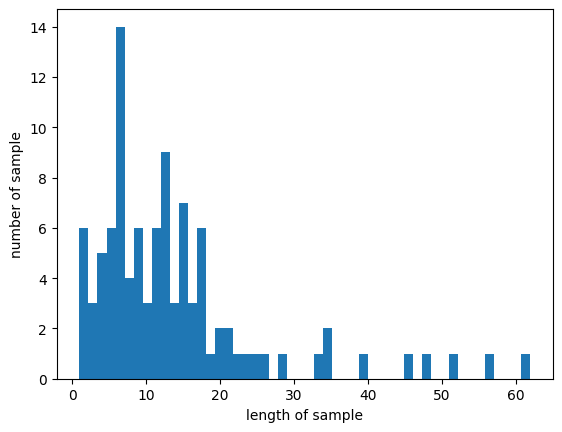

In [51]:
max_len = max(len(l) for l in encoded)
print('리뷰의 최대 길이 : %d' % max_len)
print('리뷰의 최소 길이 : %d' % min(len(l) for l in encoded))
print('리뷰의 평균 길이 : %f' % (sum(map(len, encoded)) / len(encoded)))

plt.hist([len(s) for s in encoded], bins=50)
plt.xlabel('length of sample')
plt.ylabel('number of sample')
plt.show()
# 최대 62 / 최소 1 / 평균 13.9

가장 긴 리뷰의 길이가 **62**이므로, 모든 리뷰의 길이를 62로 통일한다.

In [52]:
for line in encoded:
    if len(line) < max_len:                          # 정해준 길이보다 짧으면
        line += [word_to_index['pad']] * (max_len - len(line))   # 나머지를 'pad'(1)로 채움

print('리뷰의 최대 길이 : %d' % max(len(l) for l in encoded))   # 62
print('리뷰의 최소 길이 : %d' % min(len(l) for l in encoded))   # 62
print('리뷰의 평균 길이 : %f' % (sum(map(len, encoded)) / len(encoded)))   # 62.0

리뷰의 최대 길이 : 62
리뷰의 최소 길이 : 62
리뷰의 평균 길이 : 62.000000


In [53]:
print(encoded[:3])   # 짧은 샘플 뒤가 1(pad)로 채워진 것을 확인

[[79, 27, 9, 4, 50, 42, 80, 16, 28, 29, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [188, 5, 81, 189, 190, 191, 43, 192, 113, 5, 193, 194, 24, 114, 195, 196, 13, 51, 82, 115, 30, 43, 197, 116, 117, 31, 198, 5, 199, 200, 17, 113, 7, 68, 52, 17, 44, 201, 5, 202, 4, 203, 14, 7, 83, 32, 204, 84, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [205, 118, 206, 53, 207, 31, 208, 209, 54, 10, 25, 11, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]


> 이제 단어를 고유한 정수로 맵핑했으니, 다음 단계는 각 정수를 **단어 벡터**로 바꾸는 일이다. 단어 벡터를 얻는 방법은 크게 **원-핫 인코딩**과 **워드 임베딩**이 있으며, 주로 워드 임베딩이 사용된다. (원-핫 인코딩과 워드 임베딩은 12장에서 다룬다.)

---

이로써 9장 **자연어 처리 기초**의 핵심을 모두 정리했다. 토큰화에서 생기는 선택의 문제와 한국어 교착어의 특성을 짚었고, 정제·정규화와 불용어 제거의 목적을 이해했으며, 정규 표현식 문법과 모듈 함수를 실습으로 익혔다. 마지막으로 NSMC 데이터를 토큰화 → 단어 집합 생성 → 정수 인코딩 → 패딩까지 가공하며 딥 러닝 입력을 만드는 전체 전처리 파이프라인을 직접 구현했다. 다음 장부터는 이렇게 전처리한 텍스트를 다루는 **언어 모델(Language Model)**로 넘어간다.